In [1]:
# KNeighborsClassifier: Huấn luyện mô hình KNN cho bài toán phân loại
# KNeighborsRegressor: Huấn luyện mô hình KNN cho bài toán hồi quy (Không phải phân cụm)
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

In [3]:
def train_and_predict_knn_advanced(X_train, y_train, test_data, k=3, metric='euclidean', task='classification'):
    """
    Hàm KNN linh hoạt hỗ trợ 3 chế độ:
    - 'classification': Phân loại
    - 'regression': Hồi quy
    - 'both': Cả phân loại và hồi quy
    """
    p_value = 2 if metric == 'euclidean' else 1

    # 1. Tiền xử lý định dạng dữ liệu test
    if isinstance(test_data, pd.Series):
        test_data = pd.DataFrame([test_data])
    elif isinstance(test_data, list):
        test_data = pd.DataFrame([test_data], columns=X_train.columns)

    # Đo thời gian bắt đầu huấn luyện và dự đoán
    start_time = time.time()

    # 2. Xử lý theo từng Task do người dùng chọn
    if task == 'classification':
        model = KNeighborsClassifier(n_neighbors=k, p=p_value)
        model.fit(X_train, y_train)
        preds = model.predict(test_data)
        execution_time = time.time() - start_time
        return preds, model, execution_time

    elif task == 'regression':
        model = KNeighborsRegressor(n_neighbors=k, p=p_value)
        model.fit(X_train, y_train)
        preds = model.predict(test_data)
        execution_time = time.time() - start_time
        return preds, model, execution_time

    elif task == 'both':
        y_train_class, y_train_reg = y_train

        model_class = KNeighborsClassifier(n_neighbors=k, p=p_value)
        model_reg = KNeighborsRegressor(n_neighbors=k, p=p_value)

        model_class.fit(X_train, y_train_class)
        model_reg.fit(X_train, y_train_reg)

        pred_class = model_class.predict(test_data)
        pred_reg = model_reg.predict(test_data)

        execution_time = time.time() - start_time
        return (pred_class, pred_reg), (model_class, model_reg), execution_time

    else:
        raise ValueError("Task không hợp lệ! Vui lòng chọn 'classification', 'regression', hoặc 'both'.")

In [2]:
# Hàm vẽ đồ thị minh hoạ kết quả huấn luyện
def plot_knn_results(X_train, y_train, features_to_plot, test_point=None, test_prediction=None):
    plt.figure(figsize=(9, 6))

    unique_classes = y_train.unique()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 3 màu cho 3 loại hoa

    # Chỉ lấy 2 đặc trưng để vẽ trên đồ thị 2D
    f1, f2 = features_to_plot[0], features_to_plot[1]

    # Vẽ các điểm trong tập Train
    for i, cls in enumerate(unique_classes):
        idx = y_train == cls
        plt.scatter(X_train.loc[idx, f1], X_train.loc[idx, f2],
                    color=colors[i % len(colors)], label=f'{cls}', alpha=0.7)

    # Vẽ thêm điểm Test lên để dễ hình dung
    if test_point is not None and test_prediction is not None:
        plt.scatter(test_point[f1], test_point[f2],
                    color='red', marker='*', s=300, edgecolors='black',
                    label=f'Điểm mới (Dự đoán: {test_prediction})')

    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title('Minh hoạ phân loại KNN (dựa trên 2 đặc trưng: SepalLength & SepalWidth)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

Dữ liệu cần dự đoán (SepalLength, SepalWidth): [6.0, 3.2]
KẾT QUẢ VÀ THỜI GIAN
- Thời gian huấn luyện & dự đoán: 0.02999 giây
- [Phân loại] Loài hoa dự đoán : Iris-versicolor
- [Hồi quy] Chiều dài cánh hoa : 4.76 cm
ĐÁNH GIÁ MÔ HÌNH TRÊN CÁC TẬP DỮ LIỆU

--- Đánh giá Tác vụ Phân loại (Accuracy) ---
Accuracy trên tập Train:      86.11%
Accuracy trên tập Validation: 66.67%
Accuracy trên tập Test:       83.33%

--- Đánh giá Tác vụ Hồi quy (MSE - Càng nhỏ càng tốt) ---
MSE trên tập Train:      0.1558
MSE trên tập Validation: 0.2685
MSE trên tập Test:       0.1887
VẼ ĐỒ THỊ MINH HOẠ (TÁC VỤ PHÂN LOẠI)


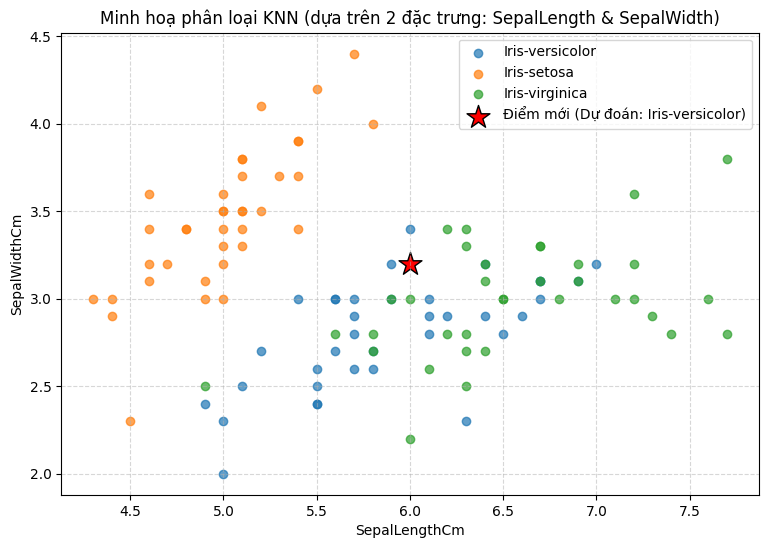

In [5]:
if __name__ == '__main__':
    # Bước 1: Chuẩn bị dữ liệu
    # Lưu ý: Thay đổi đường dẫn 'database/Iris.csv' thành 'Iris.csv' nếu file ở thư mục gốc Colab
    try:
        df = pd.read_csv('Iris.csv')
    except FileNotFoundError:
        df = pd.read_csv('database/Iris.csv')

    if 'Id' in df.columns:
        df = df.drop('Id', axis=1)

    X = df[['SepalLengthCm', 'SepalWidthCm']]
    y_class = df['Species']
    y_reg = df['PetalLengthCm']

    # Bước 2: Tiền xử lý dữ liệu và phân tách dữ liệu
    # Tách 80% (Train + Val) và 20% (Test)
    X_temp, X_test, y_class_temp, y_class_test, y_reg_temp, y_reg_test = train_test_split(
        X, y_class, y_reg, test_size=0.2, random_state=42
    )

    # Từ 80% ở trên, tách tiếp thành 90% (Train thực sự) và 10% (Validation)
    X_train, X_val, y_class_train, y_class_val, y_reg_train, y_reg_val = train_test_split(
        X_temp, y_class_temp, y_reg_temp, test_size=0.1, random_state=42
    )

    y_train_both = (y_class_train, y_reg_train)

    # Bước 3 & 4: Huấn luyện mô hình, dự đoán và tính thời gian
    new_flower = [6.0, 3.2]
    print(f"Dữ liệu cần dự đoán (SepalLength, SepalWidth): {new_flower}")

    predictions, models, exec_time = train_and_predict_knn_advanced(
        X_train,
        y_train=y_train_both,
        test_data=new_flower,
        k=5,
        task='both'
    )

    pred_class, pred_reg = predictions
    model_class, model_reg = models  # Lấy 2 mô hình ra để đánh giá

    print("=" * 45)
    print("KẾT QUẢ VÀ THỜI GIAN")
    print(f"- Thời gian huấn luyện & dự đoán: {exec_time:.5f} giây")
    print(f"- [Phân loại] Loài hoa dự đoán : {pred_class[0]}")
    print(f"- [Hồi quy] Chiều dài cánh hoa : {pred_reg[0]:.2f} cm")

    # Bước 5: Đánh giá kết quả huấn luyện
    print("=" * 45)
    print("ĐÁNH GIÁ MÔ HÌNH TRÊN CÁC TẬP DỮ LIỆU")

    # --- ĐÁNH GIÁ PHÂN LOẠI (Dùng Accuracy) ---
    print("\n--- Đánh giá Tác vụ Phân loại (Accuracy) ---")
    acc_train = accuracy_score(y_class_train, model_class.predict(X_train))
    acc_val = accuracy_score(y_class_val, model_class.predict(X_val))
    acc_test = accuracy_score(y_class_test, model_class.predict(X_test))
    print(f"Accuracy trên tập Train:      {acc_train * 100:.2f}%")
    print(f"Accuracy trên tập Validation: {acc_val * 100:.2f}%")
    print(f"Accuracy trên tập Test:       {acc_test * 100:.2f}%")

    # --- ĐÁNH GIÁ HỒI QUY (Dùng MSE) ---
    print("\n--- Đánh giá Tác vụ Hồi quy (MSE - Càng nhỏ càng tốt) ---")
    mse_train = mean_squared_error(y_reg_train, model_reg.predict(X_train))
    mse_val = mean_squared_error(y_reg_val, model_reg.predict(X_val))
    mse_test = mean_squared_error(y_reg_test, model_reg.predict(X_test))
    print(f"MSE trên tập Train:      {mse_train:.4f}")
    print(f"MSE trên tập Validation: {mse_val:.4f}")
    print(f"MSE trên tập Test:       {mse_test:.4f}")
    print("=" * 45)

    # Bước 6: Vẽ đồ thị
    print("VẼ ĐỒ THỊ MINH HOẠ (TÁC VỤ PHÂN LOẠI)")
    # Đồ thị này biểu diễn không gian phân loại, nên ta truyền nhãn y_class_train vào
    plot_knn_results(X_train, y_class_train, ['SepalLengthCm', 'SepalWidthCm'],
                     test_point=pd.Series(new_flower, index=['SepalLengthCm', 'SepalWidthCm']),
                     test_prediction=pred_class[0])